#Задание.

Реализовать суммаризацию текста.

Взять тот же датасет, который был на вебинаре, и предобученную модель для задачи суммаризации.
Проверить насколько хорошо она суммаризирует.


In [1]:
# Подключаем диск
from google.colab import drive
drive.mount('./drive')

Mounted at ./drive


In [2]:
!wget -q https://www.dropbox.com/s/43l702z5a5i2w8j/gazeta_train.txt
!wget -q https://www.dropbox.com/s/k2egt3sug0hb185/gazeta_val.txt
!wget -q https://www.dropbox.com/s/3gki5n5djs9w0v6/gazeta_test.txt

In [3]:
!ls

drive  gazeta_test.txt	gazeta_train.txt  gazeta_val.txt  sample_data


In [4]:
!pip install razdel networkx pymorphy2[fast] nltk rouge==0.3.1 summa lexrank sumy
!pip install --upgrade datasets razdel spacy networkx seaborn scipy tqdm tensorflow-text
!python -m spacy download ru_core_news_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.8/69.8 kB 7.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.3/97.3 kB 8.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 35.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 371.1/371.1 kB 40.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.7/117.7 kB 17.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 68.8 MB/s eta 0:00:00
  Created wheel for summa: filename=summa-1.2.0-py3-none-any.whl size=54388 sha256=ee4a81161a1212d98b8ed9a157bb67e67f877b22d2b20060fde5edfdf634be5a
  Stored in directory: /root/.cache/pip/whee

In [5]:
!pip -q install pymorphy2

In [6]:
!pip -q install lexrank

In [7]:
!pip -q install sumy

## Загрузим данные с помощью библиотеки datasets

In [8]:
# по сути данные те же можно пользоваться любым способом загрузки
from datasets import load_dataset

dataset = load_dataset('IlyaGusev/gazeta', revision='v1.0')['test']

/usr/local/lib/python3.10/dist-packages/datasets/load.py:1429: FutureWarning: The repository for IlyaGusev/gazeta contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/IlyaGusev/gazeta
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(


Generating train split:   0%|          | 0/52400 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5770 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5265 [00:00<?, ? examples/s]

## EDA (Exploratory data analysis)

### Dataset

Посмотрим на то, как устроен датасет

In [9]:
!head -n 1 gazeta_train.txt
!cat gazeta_train.txt | wc -l
!cat gazeta_val.txt | wc -l
!cat gazeta_test.txt | wc -l

{"url": "https://www.gazeta.ru/financial/2011/11/30/3852658.shtml", "text": "«По итогам 2011 года чистый отток может составить примерно $80 млрд, в следующем году — около $20 млрд. При этом мы ожидаем, что со второго полугодия 2012 года начнется приток капитала», — заявил «Интерфаксу» замминистра экономического развития Андрей Клепач. Официальные прогнозы по выводу капитала из России становятся все пессимистичными: еще летом власти полагали, что из страны уйдет не более $35 млрд, в сентябре Минэкономразвития назвал цифру $50 млрд, в начале ноября Центробанк пересмотрел оценку до $70 млрд. Очередное изменение прогноза было ожидаемо: по расчетам Центробанка , за январь — октябрь чистый отток капитала достиг $64 млрд, причем в последние месяцы он ускорился: в сентябре он составил $14 млрд, в октябре — $13 млрд против среднего ежемесячного оттока в $6—8 млрд в первом полугодии. «После октябрьских данных Минэкономразвития вынуждено было изменить оценку, настаивать на $70 млрд означало ожида

In [10]:
import json
import random

def read_gazeta_records(file_name, shuffle=True, sort_by_date=False):
    assert shuffle != sort_by_date
    records = []
    with open(file_name, 'r') as r:
        for line in r:
            records.append(json.loads(line))
    if sort_by_date:
        records.sort(key=lambda x: x['date'])
    if shuffle:
        random.shuffle
    return records

In [11]:
train_records = read_gazeta_records('/content/drive/MyDrive/Colab Notebooks/Summarise/gazeta_train.txt')
val_records = read_gazeta_records('/content/drive/MyDrive/Colab Notebooks/Summarise/gazeta_val.txt')
test_records = read_gazeta_records('/content/drive/MyDrive/Colab Notebooks/Summarise/gazeta_test.txt')

In [12]:
test_records[1]

{'url': 'https://www.gazeta.ru/social/2020/02/28/12980611.shtml',
 'text': 'Около 11 тысяч зрителей увидели все самое лучшее, что есть на сегодняшний день в культуре Бурятии. В Кремле выступил Бурятский государственный академический театр оперы и балета, Национальный цирк, Бурятский национальный театр песни и танца «Байкал», ставший победителем шоу «Танцуют все!» на телеканале «Россия», а также другие профессиональные и самодеятельные коллективы региона. Более 300 артистов из одного региона на главной сцене страны - похоже это рекорд России. Зрителям рассказали, что Республике Бурятия, чье население составляет 1 миллион человек, сохранилась и развивается культура десятков национальностей, включая русских, бурятов, староверов (семейских), эвенков. И все они были представлены в Москве. Как писали после шоу зрители в соцсетях: «А мы думали, что в Бурятии только буряты живут…». Для неподготовленного зрителя это вообще были вечера открытий. Например, когда еще в Кремлевском дворце выстраива

In [13]:
train_records[1].keys()

dict_keys(['url', 'text', 'title', 'summary', 'date'])

In [14]:
print(min([record['date'] for record in train_records]), end=' - ')
print(max([record['date'] for record in train_records]))
print(min([record['date'] for record in val_records]), end=' - ')
print(max([record['date'] for record in val_records]))
print(min([record['date'] for record in test_records]), end=' - ')
print(max([record['date'] for record in test_records]))

2010-06-01 10:35:49 - 2019-05-31 23:56:26
2019-06-01 08:30:00 - 2019-09-30 23:11:23
2019-10-01 08:23:02 - 2020-03-23 22:16:23


In [15]:
from collections import Counter, namedtuple
import razdel
import pymorphy2

Stats = namedtuple('Stats', 'vocabulary,lemma_vocabulary,words_counts,unique_words_counts')

def collect_stats(records, lower=True, text_max_words=3000, summary_max_words=100, nrows=1000):
    morph = pymorphy2.MorphAnalyzer()

    text_stats = Stats(Counter(),  Counter(), list(), list())
    summary_stats = Stats(Counter(),  Counter(), list(), list())

    def update_record_field_stats(field, stats, max_words):
        words = [word.text for word in razdel.tokenize(field)][:max_words]
        lemmas = [morph.parse(word)[0].normal_form for word in words]
        stats.vocabulary.update(words)
        stats.lemma_vocabulary.update(lemmas)
        stats.words_counts.append(len(words))
        stats.unique_words_counts.append(len(set(words)))

    for i, record in enumerate(records):
        if i >= nrows:
            break
        text = record['text']
        text = text if not lower else text.lower()
        update_record_field_stats(text, text_stats, text_max_words)

        summary = record['summary']
        summary = summary if not lower else summary.lower()
        summary_words = [word.text for word in razdel.tokenize(summary)]
        update_record_field_stats(summary, summary_stats, summary_max_words)
    return text_stats, summary_stats

In [16]:
train_text_stats, train_summary_stats = collect_stats(train_records)
print('Train texts vocabulary size: ', len(train_text_stats.vocabulary))
print('Train texts lemma vocabulary size: ', len(train_text_stats.lemma_vocabulary))
print('Train summaries vocabulary size: ', len(train_summary_stats.vocabulary))
print('Train summaries lemma vocabulary size: ', len(train_summary_stats.lemma_vocabulary))
print('Train common lemmas summary vs text: ', len(set(train_text_stats.lemma_vocabulary.keys()) & set(train_summary_stats.lemma_vocabulary.keys())))

Train texts vocabulary size:  82978
Train texts lemma vocabulary size:  37851
Train summaries vocabulary size:  15441
Train summaries lemma vocabulary size:  9030
Train common lemmas summary vs text:  8652


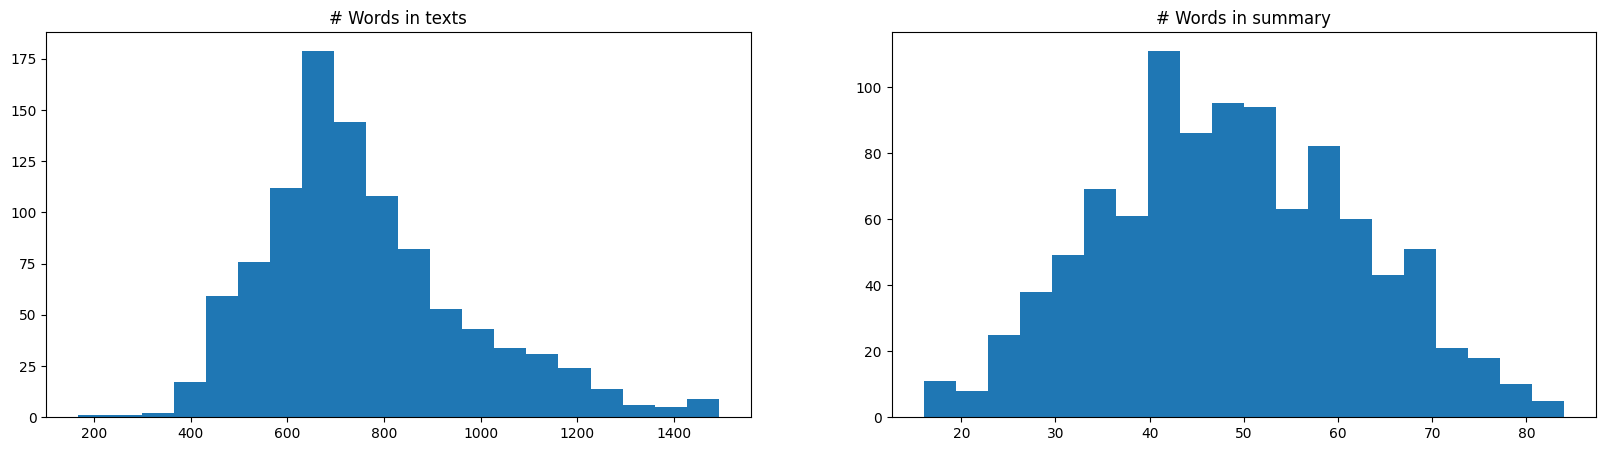

In [17]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(20, 5))
axs[0].hist(train_text_stats.words_counts, 20)
axs[0].set_title('# Words in texts')

axs[1].hist(train_summary_stats.words_counts, 20)
axs[1].set_title('# Words in summary')
plt.show()

In [20]:
!pip -q install rouge

In [21]:
from nltk.translate.bleu_score import corpus_bleu
from rouge import Rouge

def calc_scores(references, predictions, metric='all'):
    print('Count:', len(predictions))
    print('Ref:', references[-1])
    print('Hyp:', predictions[-1])

    if metric in ('bleu', 'all'):
        print('BLEU: ', corpus_bleu([[r] for r in references], predictions))
    if metric in ('rouge', 'all'):
        rouge = Rouge()
        scores = rouge.get_scores(predictions, references, avg=True)
        print('ROUGE: ', scores)

In [22]:
import razdel

def calc_lead_n_score(records, n=3, lower=True, nrows=1000):
    references = []
    predictions = []

    for i, record in enumerate(records):
        if i >= nrows:
            break

        summary = record['summary']
        summary = summary if not lower else summary.lower()
        references.append(summary)

        text = record['text']
        text = text if not lower else text.lower()
        sentences = [sentence.text for sentence in razdel.sentenize(text)]
        prediction = ' '.join(sentences[:n])
        predictions.append(prediction)

    calc_scores(references, predictions)

calc_lead_n_score(test_records, n=1)

Count: 1000
Ref: телеканал «спас» запускает реалити-шоу «остров», участникам которого предстоит месяц жить и работать в нило-столобенской пустыни на озере селигер. организаторы отметили, что это беспрецедентный подобный проект на телевидении. участникам шоу будет, где поработать — в монастыре работают свечной, молочный и столярный цеха, есть коровник, конюшня, пасека.
Hyp: православный телеканал «спас», учредителем которого является московская патриархия, запускает реалити-шоу «остров», участникам которого предстоит месяц жить и работать в нило-столобенской пустыни на озере селигер в тверской области.
BLEU:  0.19177311186434495
ROUGE:  {'rouge-1': {'r': 0.37762764047433917, 'p': 0.22208274285774904, 'f': 0.23804097238957525}, 'rouge-2': {'r': 0.15833772153385062, 'p': 0.09647636782929753, 'f': 0.10027796832321115}, 'rouge-l': {'r': 0.34937017731940756, 'p': 0.2022959168891477, 'f': 0.21799992093276083}}


## Метод Луна

In [23]:
# Делаем предобработку

import razdel
import spacy

# Список частей речи, которые мы не хотим считать значимыми.
# Подбирался на глаз.
BAD_POS = ('PREP', 'NPRO', 'CONJ', 'PRCL', 'NUMR', 'PRED', 'INTJ', 'PUNCT',
           'CCONJ', 'ADP', 'DET', 'ADV')

# Загрузка модели для частеречной разметки.
spacy_model = spacy.load('ru_core_news_md')


# Метод для разбиения текста на предложения.
def sentenize(text):
    return [s.text for s in razdel.sentenize(text)]


# Метод для токенизации предложения.
def tokenize_sentence(sentence):
    sentence = sentence.strip().replace('\xa0', '')
    tokens = [token.lemma_ for token in spacy_model(sentence) if token.pos_ not in BAD_POS]
    tokens = [token for token in tokens if len(token) > 2]
    return tokens


# Метод для токенизации всего текста.
def tokenize_text(text):
    all_tokens = []
    for sentence in sentenize(text):
        all_tokens.extend(tokenize_sentence(sentence))
    return all_tokens


# Пример работы обоих методов.
text = test_records[0]['text']
sentences = sentenize(text)
print(tokenize_sentence(sentences[0]))
print(tokenize_text(text))

['американский', 'аэрокосмический', 'агентство', 'nasa', 'огласить', 'название', 'четыре', 'космический', 'миссия', 'которые', 'скорый', 'время', 'мочь', 'быть', 'выбрать', 'реализация', 'запуск', 'которых', 'мочь', 'состояться', 'конец', 'десятилетие']
['американский', 'аэрокосмический', 'агентство', 'nasa', 'огласить', 'название', 'четыре', 'космический', 'миссия', 'которые', 'скорый', 'время', 'мочь', 'быть', 'выбрать', 'реализация', 'запуск', 'которых', 'мочь', 'состояться', 'конец', 'десятилетие', 'четыре', 'проект', 'стать', 'полуфиналист', 'конкурс', 'объявить', 'американский', 'научный', 'команда', 'котором', 'участвовать', 'десять', 'миссия', 'они', 'были', 'отобрать', 'критерий', 'потенциальный', 'польза', 'наука', 'технический', 'осуществимость', 'проект', 'рамка', 'программа', 'discovery', 'nasa', 'заниматься', 'планирование', 'миссия', 'которые', 'призваны', 'дать', 'ответ', 'фундаментальный', 'вопрос', 'происхождение', 'тело', 'солнечный', 'система', 'возможный', 'наличие

In [24]:
from collections import Counter

class LuhnSummarizer:
    """
    Метод Луна.
    Основано на https://github.com/miso-belica/sumy/blob/main/sumy/summarizers/luhn.py
    Оригинальная статья: https://courses.ischool.berkeley.edu/i256/f06/papers/luhn58.pdf
    """
    def __init__(
        self,
        significant_percentage = 0.4, # 40% самых частотных токенов мы считаем значимыми.
        min_token_freq = 2, # Кроме того, слова должны встречаться минимум 2 раза.
        max_gap_size = 4, # Максимальное количество подряд идущих незначимых токенов в промежутках.
        verbose = False # Отладочный вывод для наглядности.
    ):
        self.significant_percentage = significant_percentage
        self.min_token_freq = min_token_freq
        self.max_gap_size = max_gap_size
        self.chunk_ending_mask = [0] * self.max_gap_size
        self.verbose = verbose

    def __call__(self, text, target_sentences_count):
        # Считаем значимые токены.
        all_significant_tokens = self._get_significant_tokens(text)
        if self.verbose:
            print('Значимые токены: ', all_significant_tokens)

        # Считаем значимости предложений.
        ratings = []
        for sentence_index, sentence in enumerate(sentenize(text)):
            # Значимость предложений - максимум из значимостей промежутков.
            sentence_rating = max(self._get_chunk_ratings(sentence, all_significant_tokens))
            if self.verbose:
                print(f'\tПРЕДЛОЖЕНИЕ. Значимость: {sentence_rating}, текст: {sentence}')
            ratings.append((sentence_rating, sentence_index))

        # Сортируем предложения по значимости.
        ratings.sort(reverse=True)

        # Оставляем топовые и собираем реферат.
        ratings = ratings[:target_sentences_count]
        indices = [index for _, index in ratings]
        indices.sort()
        return ' '.join([sentences[index] for index in indices])

    def _get_significant_tokens(self, text):
        """ Метод для подсчёта того, какие токены являются значимыми. """
        tokens_counter = Counter(tokenize_text(text))
        significant_tokens_max_count = int(len(tokens_counter) * self.significant_percentage)
        significant_tokens = tokens_counter.most_common(significant_tokens_max_count)
        significant_tokens = {token for token, cnt in significant_tokens if cnt >= self.min_token_freq}
        return significant_tokens

    def _get_chunk_ratings(self, sentence, significant_tokens):
        """ Разбиваем предложение на промежтуки и считаем их значимости. """

        tokens = tokenize_sentence(sentence)

        chunks, masks = [], []
        in_chunk = False
        for token in tokens:
            is_significant_token = token in significant_tokens

            if is_significant_token and not in_chunk:
                in_chunk = True
                masks.append([int(is_significant_token)])
                chunks.append([token])
            elif in_chunk:
                last_mask = masks[-1]
                last_mask.append(int(is_significant_token))
                last_chunk = chunks[-1]
                last_chunk.append(token)
            if not chunks:
                continue

            # Проверяем на наличие 4 подряд идущих незначимых токенов.
            # Если встретили - завершаем промежуток.
            last_chunk_ending_mask = masks[-1][-self.max_gap_size:]
            if last_chunk_ending_mask == self.chunk_ending_mask:
                in_chunk = False

        ratings = []
        for chunk, mask in zip(chunks, masks):
            rating = self._get_chunk_rating(mask, chunk)
            ratings.append(rating)
        return ratings

    def _get_chunk_rating(self, original_mask, chunk):
        """ Подсчёт значимости одного промежутка """

        # Убираем незначимые токены в конце промежутка
        original_mask = ''.join(map(str, original_mask))
        mask = original_mask.rstrip('0')

        end_index = original_mask.rfind('1') + 1
        chunk = chunk[:end_index]
        assert len(mask) == len(chunk)
        chunk = ' '.join(chunk)

        # Считаем значимость
        words_count = len(mask)
        assert words_count > 0
        significant_words_count = mask.count('1')
        assert significant_words_count > 0

        rating = significant_words_count * significant_words_count / words_count
        if self.verbose:
            print(f'ПРОМЕЖУТОК. Значимость: {rating}, маска: {mask}, текст: {chunk}')
        return rating

In [25]:
luhn = LuhnSummarizer(verbose=False)
summary = luhn(text, 3)
print()
print(f'Текст: {test_records[0]["text"]}')
print(f'Итоговый реферат: {summary}')
print(f'Правильный реферат: {test_records[0]["summary"]}')


Текст: Американское аэрокосмическое агентство NASA огласило названия четырех космических миссий, которые в скором времени могут быть выбраны для реализации и запуск которых может состояться уже в конце этого десятилетия. Эти четыре проекта стали полуфиналистами конкурса, объявленного среди американских научных команд, в котором участвовало более десяти миссий. Все они были отобраны по критериям потенциальной пользы для науки и технической осуществимости проекта. В рамках программы Discovery NASA занимается планированием миссий, которые призваны дать ответы на фундаментальные вопросы о происхождении тел Солнечной системы и возможному наличию жизни на них. «Эти выбранные миссии могут трансформировать наше восприятие некоторых из наиболее активных и сложных миров в Солнечной системе, — заявил Томас Зурбучен, помощник директора NASA по науке. — Исследование каждого из этих небесных тел поможет раскрыть секреты о том, как они и им подобные объекты образовались в космосе». Каждый проект из 

можно сделать то же но на трансформерах, взять бертовые эмбединги

## Lexrank
* Original paper: https://arxiv.org/pdf/1109.2128.pdf
* lexrank library: https://github.com/crabcamp/lexrank

In [26]:
def calc_method_score(records, predict_func, nrows=1000):
    references = []
    predictions = []

    for i, record in enumerate(records):
        if nrows is not None and i >= nrows:
            break
        summary = record['summary']
        text = record['text']
        prediction = predict_func(text, summary)
        references.append(summary)
        predictions.append(prediction)

    calc_scores(references, predictions)

In [27]:
import lexrank
from lexrank import LexRank
from lexrank.mappings.stopwords import STOPWORDS


def predict_lex_rank(text, summary, lxr, summary_size=3, threshold=None):
    sentences = [s.text for s in razdel.sentenize(text)]
    prediction = lxr.get_summary(sentences, summary_size=summary_size, threshold=threshold)
    prediction = ' '.join(prediction)
    return prediction


sentences = [[s.text for s in razdel.sentenize(r['text'])] for r in test_records]
lxr = LexRank(sentences, stopwords=STOPWORDS['ru'])
calc_method_score(test_records, lambda x, y: predict_lex_rank(x, y, lxr))

Count: 1000
Ref: Телеканал «Спас» запускает реалити-шоу «Остров», участникам которого предстоит месяц жить и работать в Нило-Столобенской пустыни на озере Селигер. Организаторы отметили, что это беспрецедентный подобный проект на телевидении. Участникам шоу будет, где поработать — в монастыре работают свечной, молочный и столярный цеха, есть коровник, конюшня, пасека.
Hyp: РПЦ же нередко критикует СМИ. Критиковали в РПЦ и популярность футбола – об этом заявлял также Смирнов. В июне нынешнего года сообщалось, что РПЦ планирует сделать из Сергиева Посада «православный Ватикан».
BLEU:  0.3585872220880093
ROUGE:  {'rouge-1': {'r': 0.2055701577098893, 'p': 0.18137864753781832, 'f': 0.1866598392888999}, 'rouge-2': {'r': 0.06670656927927147, 'p': 0.05407660852215697, 'f': 0.05775558829470266}, 'rouge-l': {'r': 0.18766952121068614, 'p': 0.16619633248764337, 'f': 0.1707256638500182}}


## LSA
* One of the original papers: https://www.cs.bham.ac.uk/~pxt/IDA/text_summary.pdf
* sumy library: https://github.com/miso-belica/sumy

In [28]:
from sumy.summarizers.lsa import LsaSummarizer
from sumy.nlp.tokenizers import Tokenizer
from sumy.parsers.plaintext import PlaintextParser
import nltk; nltk.download('punkt');


def predict_lsa(text, summary, lsa_summarizer, tokenizer, summary_size=3):
    parser = PlaintextParser.from_string(text, tokenizer)
    predicted_summary = lsa_summarizer(parser.document, summary_size)
    predicted_summary = ' '.join([str(s) for s in predicted_summary])
    return predicted_summary

lsa_summarizer = LsaSummarizer()
tokenizer = Tokenizer('russian')
calc_method_score(test_records, lambda x, y: predict_lsa(x, y, lsa_summarizer, tokenizer))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Count: 1000
Ref: Телеканал «Спас» запускает реалити-шоу «Остров», участникам которого предстоит месяц жить и работать в Нило-Столобенской пустыни на озере Селигер. Организаторы отметили, что это беспрецедентный подобный проект на телевидении. Участникам шоу будет, где поработать — в монастыре работают свечной, молочный и столярный цеха, есть коровник, конюшня, пасека.
Hyp: Известный миссионер, председатель Синодального отдела МП по взаимодействию с Вооруженными силами и правоохранительными учреждениями протоиерей Дмитрий Смирнов выразил надежду, что проект даст благие результаты. Стоит отметить, что участникам шоу будет, где поработать — в монастыре работают свечной, молочный и столярный цеха, есть коровник, конюшня, пасека. По его словам, такая зависимость сродни алкогольной или наркотической — электронные устройства лишают человека свободы и приводят к «дегуманизации» личности, уводя в виртуальную реальность.
BLEU:  0.28906733300518317
ROUGE:  {'rouge-1': {'r': 0.18982549504054286, '

## Oracle summary

Для сведения задачи к extractive summarization мы должны выбрать те предложения из оригинального текста, которые наиболее похожи на наше целевое summary по нашим метрикам.

In [29]:
import copy

def build_oracle_summary_greedy(text, gold_summary, calc_score, lower=True, max_sentences=30):
    '''
    Жадное построение oracle summary
    '''
    gold_summary = gold_summary.lower() if lower else gold_summary
    # Делим текст на предложения
    sentences = [sentence.text.lower() if lower else sentence.text for sentence in razdel.sentenize(text)][:max_sentences]
    n_sentences = len(sentences)
    oracle_summary_sentences = set()

    score = -1.0
    summaries = []
    for _ in range(n_sentences):
        for i in range(n_sentences):
            if i in oracle_summary_sentences:
                continue
            current_summary_sentences = copy.copy(oracle_summary_sentences)
            # Добавляем какое-то предложения к уже существующему summary
            current_summary_sentences.add(i)
            current_summary = ' '.join([sentences[index] for index in sorted(list(current_summary_sentences))])
            # Считаем метрики
            current_score = calc_score(current_summary, gold_summary)
            summaries.append((current_score, current_summary_sentences))
        # Если получилось улучшить метрики с добавлением какого-либо предложения, то пробуем добавить ещё
        # Иначе на этом заканчиваем
        best_summary_score, best_summary_sentences = max(summaries)
        if best_summary_score <= score:
            break
        oracle_summary_sentences = best_summary_sentences
        score = best_summary_score
    oracle_summary = " ".join([sentences[index] for index in sorted(list(oracle_summary_sentences))])
    return oracle_summary, oracle_summary_sentences

def calc_single_score(pred_summary, gold_summary, rouge):
    return rouge.get_scores([pred_summary], [gold_summary], avg=True)['rouge-2']['f']

In [30]:
from tqdm.notebook import tqdm
import razdel

def calc_oracle_score(records, nrows=1000, lower=True):
    references = []
    predictions = []
    rouge = Rouge()

    for i, record in tqdm(enumerate(records)):
        if i >= nrows:
            break

        summary = record['summary']
        summary = summary if not lower else summary.lower()
        references.append(summary)

        text = record['text']
        predicted_summary, _ = build_oracle_summary_greedy(text, summary, calc_score=lambda x, y: calc_single_score(x, y, rouge))
        predictions.append(predicted_summary)

    calc_scores(references, predictions)


calc_oracle_score(test_records)

0it [00:00, ?it/s]

Count: 1000
Ref: телеканал «спас» запускает реалити-шоу «остров», участникам которого предстоит месяц жить и работать в нило-столобенской пустыни на озере селигер. организаторы отметили, что это беспрецедентный подобный проект на телевидении. участникам шоу будет, где поработать — в монастыре работают свечной, молочный и столярный цеха, есть коровник, конюшня, пасека.
Hyp: православный телеканал «спас», учредителем которого является московская патриархия, запускает реалити-шоу «остров», участникам которого предстоит месяц жить и работать в нило-столобенской пустыни на озере селигер в тверской области. в комментарии также отмечается, что это беспрецедентный подобный проект на телевидении. стоит отметить, что участникам шоу будет, где поработать — в монастыре работают свечной, молочный и столярный цеха, есть коровник, конюшня, пасека.
BLEU:  0.531336150784986
ROUGE:  {'rouge-1': {'r': 0.3661389123393327, 'p': 0.4053281117404892, 'f': 0.36951810858804146}, 'rouge-2': {'r': 0.2059449963901

## RNN

In [31]:
import pandas as pd

In [32]:
df_train = pd.DataFrame(train_records)

In [33]:
df_test = pd.DataFrame(test_records)
df_test[:3]

,url,text,title,summary,date
0,https://www.gazeta.ru/science/2020/02/14_a_129...,Американское аэрокосмическое агентство NASA ог...,"Венера, Ио или Тритон: куда полетит NASA","В NASA назвали четыре миссии в дальний космос,...",2020-02-14 16:39:11
1,https://www.gazeta.ru/social/2020/02/28/129806...,Около 11 тысяч зрителей увидели все самое лучш...,«Люди в Бурятии очень талантливые»,25 и 26 февраля в Кремлевском дворце съездов п...,2020-02-28 10:44:13
2,https://www.gazeta.ru/politics/2019/11/07_a_12...,7 ноября в Белоруссии прошли выборы членов сов...,Вспомнить СССР: как Лукашенко провел выборы,В Белоруссии в день годовщины Октябрьской рево...,2019-11-07 19:55:08


In [34]:
df_train[:5]

,url,text,title,summary,date
0,https://www.gazeta.ru/financial/2011/11/30/385...,«По итогам 2011 года чистый отток может состав...,Прогноз не успевает за оттоком,"В 2011 году из России уйдет $80 млрд, считают ...",2011-11-30 18:33:39
1,https://www.gazeta.ru/business/2013/01/24/4939...,Российское подразделение интернет-корпорации G...,Google закончил поиск,"Юлия Соловьева, экс-директор холдинга «Профмед...",2013-01-24 18:20:09
2,https://www.gazeta.ru/social/2018/02/06/116393...,Басманный районный суд Москвы вечером 6 феврал...,«Фигуранты дела могут давить на свидетелей»,Суд арестовал на два месяца четверых экс-чинов...,2018-02-06 21:21:14
3,https://www.gazeta.ru/business/2013/06/21/5388...,Как повлияло вступление в ВТО на конкурентносп...,«С последних традиционно «отжимают» больше»,Мнения предпринимателей по поводу вступления в...,2013-06-21 17:43:50
4,https://www.gazeta.ru/culture/2014/12/27/a_636...,К третьему сезону «Голос» на Первом канале ста...,Третий «Голос» за Градского,На Первом канале завершился третий сезон шоу «...,2014-12-27 01:10:01


In [35]:
df_train['summary_clean'] = df_train['summary'].apply(lambda v: 'BOS ' + v + ' EOS')
df_test['summary_clean'] = df_test['summary'].apply(lambda v: 'BOS ' + v + ' EOS')
df_train['summary_clean'][:5]

0    BOS В 2011 году из России уйдет $80 млрд, счит...
1    BOS Юлия Соловьева, экс-директор холдинга «Про...
2    BOS Суд арестовал на два месяца четверых экс-ч...
3    BOS Мнения предпринимателей по поводу вступлен...
4    BOS На Первом канале завершился третий сезон ш...
Name: summary_clean, dtype: object

In [36]:
MAX_TRAIN_SAMPLE = 1000
MAX_TEST_SAMPLE = 200

df_train = df_train[:MAX_TRAIN_SAMPLE]
df_test = df_test[:MAX_TEST_SAMPLE]

In [37]:
import tensorflow as tf

from keras.preprocessing.text import Tokenizer
from keras.preprocessing.text import text_to_word_sequence
from keras.preprocessing.sequence import pad_sequences

In [38]:
max_len_text = 700
max_len_sum = 70

In [39]:
#tok_text = Tokenizer(oov_token='UNK')
tok_text = Tokenizer()
tok_text.fit_on_texts(df_train['text'])
x_train_tok = tok_text.texts_to_sequences(df_train['text'])
x_test_tok = tok_text.texts_to_sequences(df_test['text'])

In [40]:
text_vocab_size=len(tok_text.word_index)+1

padded_x_train = pad_sequences(x_train_tok, maxlen=max_len_text, padding='post', truncating='post')
padded_x_test = pad_sequences(x_test_tok, maxlen=max_len_text, padding='post', truncating='post')

In [41]:
#tok_sum = Tokenizer(oov_token='UNK')
tok_sum = Tokenizer()
tok_sum.fit_on_texts(df_train['summary_clean'])
x_train_sum = tok_sum.texts_to_sequences(df_train['summary_clean'])
x_test_sum = tok_sum.texts_to_sequences(df_test['summary_clean'])

sum_vocab_size=len(tok_sum.word_index)+1

padded_x_train_sum = pad_sequences(x_train_sum, maxlen=max_len_sum, padding='post', truncating='post')
padded_x_test_sum = pad_sequences(x_test_sum, maxlen=max_len_sum, padding='post', truncating='post')

In [42]:
padded_x_train_sum.shape

(1000, 70)

In [43]:
reverse_text_index=tok_text.index_word
reverse_sum_index=tok_sum.index_word
sum_wordindex=tok_sum.word_index

### Model

In [44]:
from keras.layers import Input, LSTM, GRU, Embedding, TimeDistributed, Softmax, Dense, RepeatVector, Concatenate, Dense
from keras.models import Model

In [45]:
latent_dim = 300
embedding_dim=200

# Encoder
encoder_inputs = Input(shape=(max_len_text,))

#embedding layer
enc_emb =  Embedding(text_vocab_size, embedding_dim, trainable=True)(encoder_inputs)

#encoder lstm 1
encoder_lstm1 = LSTM(latent_dim, return_sequences=True, return_state=True, dropout=0.4, recurrent_dropout=0.4)
encoder_output1, state_h1, state_c1 = encoder_lstm1(enc_emb)

#encoder lstm 2
encoder_lstm2 = LSTM(latent_dim, return_sequences=True,return_state=True,dropout=0.4, recurrent_dropout=0.4)
encoder_output2, state_h2, state_c2 = encoder_lstm2(encoder_output1)

#encoder lstm 3
encoder_lstm3=LSTM(latent_dim, return_state=True, return_sequences=True,dropout=0.4,recurrent_dropout=0.4)
encoder_outputs, state_h, state_c= encoder_lstm3(encoder_output2) #encoder_lstm3(encoder_output2)

# Set up the decoder, using `encoder_states` as initial state.
decoder_inputs = Input(shape=(None,))

#embedding layer
dec_emb_layer = Embedding(sum_vocab_size, embedding_dim, trainable=True)
dec_emb = dec_emb_layer(decoder_inputs)

decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True,dropout=0.4,recurrent_dropout=0.2)
decoder_outputs, decoder_fwd_state, decoder_back_state = decoder_lstm(dec_emb, initial_state=[state_h, state_c])

#dense layer
decoder_dense =  TimeDistributed(Dense(sum_vocab_size, activation='softmax'))
decoder_outputs = decoder_dense(decoder_outputs)

# Define the model
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 700)]                0         []                            
                                                                                                  
 embedding (Embedding)       (None, 700, 200)             1766400   ['input_1[0][0]']             
                                                          0                                       
                                                                                                  
 lstm (LSTM)                 [(None, 700, 300),           601200    ['embedding[0][0]']           
                              (None, 300),                                                        
                              (None, 300)]                                                    

In [46]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

In [47]:
model.compile(optimizer='Adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [48]:
history = model.fit([padded_x_train, padded_x_train_sum[:,:-1]], padded_x_train_sum.reshape(padded_x_train_sum.shape[0],padded_x_train_sum.shape[1], 1)[:,1:],
                    epochs=3,
                    validation_data=([padded_x_test, padded_x_test_sum[:,:-1]], padded_x_test_sum.reshape(padded_x_test_sum.shape[0], padded_x_test_sum.shape[1], 1)[:,1:]),
                    batch_size=16)

Epoch 1/3
63/63 [==============================] - 536s 8s/step - loss: 6.7395 - accuracy: 0.3773 - val_loss: 4.3467 - val_accuracy: 0.4946
Epoch 2/3
63/63 [==============================] - 516s 8s/step - loss: 5.3588 - accuracy: 0.3930 - val_loss: 3.9021 - val_accuracy: 0.5251
Epoch 3/3
63/63 [==============================] - 510s 8s/step - loss: 5.1211 - accuracy: 0.4101 - val_loss: 3.8894 - val_accuracy: 0.5299


In [49]:
# Encode the input sequence to get the feature vector
encoder_model = Model(inputs=encoder_inputs,outputs=[encoder_outputs, state_h, state_c])

# Decoder setup
# Below tensors will hold the states of the previous time step
decoder_state_input_h = Input(shape=(latent_dim,))
decoder_state_input_c = Input(shape=(latent_dim,))
decoder_hidden_state_input = Input(shape=(max_len_text, latent_dim))

# Get the embeddings of the decoder sequence
dec_emb2= dec_emb_layer(decoder_inputs)
# To predict the next word in the sequence, set the initial states to the states from the previous time step
decoder_outputs2, state_h2, state_c2 = decoder_lstm(dec_emb2, initial_state=[decoder_state_input_h, decoder_state_input_c])

# A dense softmax layer to generate prob dist. over the target vocabulary
decoder_outputs2 = decoder_dense(decoder_outputs2)

# Final decoder model
decoder_model = Model(
    [decoder_inputs] + [decoder_hidden_state_input, decoder_state_input_h, decoder_state_input_c],
    [decoder_outputs2] + [state_h2, state_c2])

In [50]:
import numpy as np

def decode_sequence(input_seq):
    # Encode the input as state vectors.
    e_out, e_h, e_c = encoder_model.predict(input_seq)

    # Generate empty target sequence of length 1.
    target_seq = np.zeros((1,1))

    # Populate the first word of target sequence with the start word.
    target_seq[0, 0] = sum_wordindex['bos']

    stop_condition = False
    decoded_sentence = ''
    while not stop_condition:

        output_tokens, h, c = decoder_model.predict([target_seq] + [e_out, e_h, e_c])

        # Sample a token
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_token = reverse_sum_index[sampled_token_index]

        if(sampled_token!='eos'):
            decoded_sentence += ' '+sampled_token

        # Exit condition: either hit max length or find stop word.
        if (sampled_token == 'eos'  or len(decoded_sentence.split()) >= (max_len_sum - 1)):
            stop_condition = True

        # Update the target sequence (of length 1).
        target_seq = np.zeros((1,1))
        target_seq[0, 0] = sampled_token_index

        # Update internal states
        e_h, e_c = h, c

    return decoded_sentence

In [51]:
def seq2summary(input_seq):
    newString=''
    for i in input_seq:
        if((i!=0 and i!=sum_wordindex['bos']) and i!=sum_wordindex['eos']):
            newString=newString+reverse_sum_index[i]+' '
    return newString

def seq2text(input_seq):
    newString=''
    for i in input_seq:
        if(i!=0):
            newString=newString+reverse_text_index[i]+' '
    return newString


In [52]:
for i in range(0, 3):
    #print("Review:",seq2text(padded_x_test[i]))
    print('Original summary: ', seq2summary(padded_x_test_sum[i]))

    print('Predicted summary: ', decode_sequence(padded_x_test[i].reshape(1, max_len_text)))
    print('\n')

Original summary:  в nasa назвали четыре миссии в космос которые в этом могут быть американцами среди них — две миссии по полет к и к 
1/1 [==============================] - 0s 21ms/step
Predicted summary:   в в в в в в в в в в в в в в в в в в в в в в в в в в в в в в в в в в в в в в разыскивают камчатке впп впп впп впп впп впп впп впп впп впп впп впп впп впп впп впп впп впп впп впп впп впп впп впп впп впп впп впп впп


Original summary:  25 и 26 февраля в праздновали — новый год центр российского и один из регионов страны где новый год официально дважды 
1/1 [==============================] - 0s 20ms/step
Predicted summary:   в в в в в в в в в в в в в в в в в в в в в в в в в в в в в в в в в в в в в в разыскивают камчатке впп впп впп впп впп впп впп впп впп впп впп впп впп впп впп впп впп впп впп впп впп впп впп впп впп впп впп впп впп


Original summary:  в белоруссии в день революции выбрали членов палаты парламента сегодняшнее голосование — основной части процесса через десять дней в

## Attention

In [53]:
from keras.layers import GRU, AdditiveAttention

In [54]:
df_train['text'],
df_train['summary_clean']

0      BOS В 2011 году из России уйдет $80 млрд, счит...
1      BOS Юлия Соловьева, экс-директор холдинга «Про...
2      BOS Суд арестовал на два месяца четверых экс-ч...
3      BOS Мнения предпринимателей по поводу вступлен...
4      BOS На Первом канале завершился третий сезон ш...
                             ...                        
995    BOS Банки исчерпывают точки роста, обеспечивав...
996    BOS В условиях экономической стагнации именно ...
997    BOS Еврочиновники приняли мандат на ведение пе...
998    BOS В Грузии в районе Панкисского ущелья постр...
999    BOS Коррупцию в России не удастся победить еще...
Name: summary_clean, Length: 1000, dtype: object

In [55]:
BUFFER_SIZE = len(padded_x_train)
BATCH_SIZE = 32
steps_per_epoch = len(padded_x_train)//BATCH_SIZE

dataset = tf.data.Dataset.from_tensor_slices((padded_x_train, padded_x_train_sum)).shuffle(BUFFER_SIZE)
dataset = dataset.batch(BATCH_SIZE, drop_remainder=True)

In [56]:
example_input_batch, example_target_batch = next(iter(dataset))
example_input_batch.shape, example_target_batch.shape

(TensorShape([32, 700]), TensorShape([32, 70]))

In [57]:
class Encoder(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim, enc_units, batch_sz):
        super(Encoder, self).__init__()
        self.batch_sz = batch_sz
        self.enc_units = enc_units
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.gru1 = tf.keras.layers.GRU(self.enc_units,
                                       return_sequences=True,
                                       return_state=True,
                                       recurrent_initializer='glorot_uniform')
        self.gru2 = tf.keras.layers.GRU(self.enc_units,
                                       return_sequences=True,
                                       return_state=True,
                                       recurrent_initializer='glorot_uniform')

    def call(self, x, hidden):
        x = self.embedding(x)
        output, state = self.gru1(x, initial_state = hidden)
        output, state = self.gru2(output, initial_state = state)
        return output, state

    def initialize_hidden_state(self):
        return tf.zeros((self.batch_sz, self.enc_units))

class Decoder(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim, dec_units, batch_sz):
        super(Decoder, self).__init__()
        self.batch_sz = batch_sz
        self.dec_units = dec_units
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.gru = tf.keras.layers.GRU(self.dec_units,
                                       return_sequences=True,
                                       return_state=True,
                                       recurrent_initializer='glorot_uniform')
        self.fc = tf.keras.layers.Dense(vocab_size)

        # used for attention
        self.attention = tf.keras.layers.AdditiveAttention()

    def call(self, x, query, value):
        # enc_output shape == (batch_size, max_length, hidden_size)
        #attention_weights = self.attention([ tf.expand_dims(query, 1), value,])
        context_vector = self.attention([tf.expand_dims(query, 1), value,])
        #context_vector = tf.squeeze(context_vector)


        # x shape after passing through embedding == (batch_size, 1, embedding_dim)
        x = self.embedding(x)
        # x shape after concatenation == (batch_size, 1, embedding_dim + hidden_size)
        x = tf.concat([context_vector, x], axis=-1)

        # passing the concatenated vector to the GRU
        output, state = self.gru(x)

        # output shape == (batch_size * 1, hidden_size)
        output = tf.reshape(output, (-1, output.shape[2]))

        # output shape == (batch_size, vocab)
        x = self.fc(output)

        return x, state

In [58]:
latent_dim = 300
embedding_dim=200

In [59]:
encoder = Encoder(text_vocab_size, embedding_dim, latent_dim, BATCH_SIZE)
decoder = Decoder(sum_vocab_size, embedding_dim, latent_dim, BATCH_SIZE)

# sample input
sample_hidden = encoder.initialize_hidden_state()
sample_output, sample_hidden = encoder(example_input_batch, sample_hidden)

In [60]:
optimizer = tf.keras.optimizers.Adam()
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, reduction='none')

def loss_function(real, pred):
  mask = tf.math.logical_not(tf.math.equal(real, 0))
  loss_ = loss_object(real, pred)

  mask = tf.cast(mask, dtype=loss_.dtype)
  loss_ *= mask

  return tf.reduce_mean(loss_)

In [61]:
@tf.function
def train_step(inp, targ, enc_hidden):
    loss = 0

    with tf.GradientTape() as tape:
        enc_output, enc_hidden = encoder(inp, enc_hidden)

        dec_hidden = enc_hidden

        dec_input = tf.expand_dims([sum_wordindex['bos']] * BATCH_SIZE, 1)

        # Teacher forcing - feeding the target as the next input
        for t in range(1, targ.shape[1]):
            # passing enc_output to the decoder
            predictions, dec_hidden = decoder(dec_input, dec_hidden, enc_output)

            loss += loss_function(targ[:, t], predictions)

            # using teacher forcing
            dec_input = tf.expand_dims(targ[:, t], 1)

    batch_loss = (loss / int(targ.shape[1]))

    variables = encoder.trainable_variables + decoder.trainable_variables

    gradients = tape.gradient(loss, variables)

    optimizer.apply_gradients(zip(gradients, variables))

    return batch_loss

In [62]:
import unicodedata
import re
import numpy as np
import os
import io
import time

In [63]:
checkpoint_dir = '/content/drive/MyDrive/Colab Notebooks/Summarise'
checkpoint_prefix = os.path.join(checkpoint_dir, 'ckpt')
checkpoint = tf.train.Checkpoint(optimizer=optimizer,
                                 encoder=encoder,
                                 decoder=decoder)

In [64]:
EPOCHS = 20

for epoch in range(EPOCHS):
    start = time.time()

    enc_hidden = encoder.initialize_hidden_state()
    total_loss = 0

    for (batch, (inp, targ)) in enumerate(dataset.take(steps_per_epoch)):
        batch_loss = train_step(inp, targ, enc_hidden)
        total_loss += batch_loss

        if batch % 10 == 0:
            print(f'Epoch {epoch + 1} Batch {batch} Loss {batch_loss.numpy():.4f}')
    # saving (checkpoint) the model every 2 epochs
    if (epoch + 1) % 2 == 0:
        checkpoint.save(file_prefix = checkpoint_prefix)

    print(f'Epoch {epoch + 1} Loss {total_loss / steps_per_epoch:.4f}')
    print(f'Time taken for 1 epoch {time.time() - start} sec\n')

Epoch 1 Batch 0 Loss 5.6735
Epoch 1 Batch 10 Loss 5.7975
Epoch 1 Batch 20 Loss 5.5449
Epoch 1 Batch 30 Loss 5.2201
Epoch 1 Loss 5.5421
Time taken for 1 epoch 106.94160008430481 sec

Epoch 2 Batch 0 Loss 5.1550
Epoch 2 Batch 10 Loss 5.2556
Epoch 2 Batch 20 Loss 5.2518
Epoch 2 Batch 30 Loss 5.2569
Epoch 2 Loss 5.1629
Time taken for 1 epoch 22.61781072616577 sec

Epoch 3 Batch 0 Loss 5.1416
Epoch 3 Batch 10 Loss 5.2710
Epoch 3 Batch 20 Loss 5.3841
Epoch 3 Batch 30 Loss 5.2108
Epoch 3 Loss 5.0400
Time taken for 1 epoch 18.504369497299194 sec

Epoch 4 Batch 0 Loss 4.9462
Epoch 4 Batch 10 Loss 5.0315
Epoch 4 Batch 20 Loss 5.3575
Epoch 4 Batch 30 Loss 4.5717
Epoch 4 Loss 4.9703
Time taken for 1 epoch 18.011831283569336 sec

Epoch 5 Batch 0 Loss 4.5646
Epoch 5 Batch 10 Loss 4.8850
Epoch 5 Batch 20 Loss 4.4793
Epoch 5 Batch 30 Loss 5.3133
Epoch 5 Loss 4.9157
Time taken for 1 epoch 17.81310272216797 sec

Epoch 6 Batch 0 Loss 4.9826
Epoch 6 Batch 10 Loss 4.9524
Epoch 6 Batch 20 Loss 4.6725
Epoch 

In [65]:
tok_sum.word_index

{'в': 1,
 'bos': 2,
 'eos': 3,
 'и': 4,
 'на': 5,
 'с': 6,
 'по': 7,
 'не': 8,
 'что': 9,
 'за': 10,
 'из': 11,
 '—': 12,
 'а': 13,
 'к': 14,
 'о': 15,
 'россии': 16,
 'его': 17,
 'от': 18,
 'для': 19,
 'после': 20,
 'сша': 21,
 'как': 22,
 'но': 23,
 'он': 24,
 'года': 25,
 'до': 26,
 'будет': 27,
 'это': 28,
 'может': 29,
 'также': 30,
 'у': 31,
 'эксперты': 32,
 'при': 33,
 'уже': 34,
 'году': 35,
 'лет': 36,
 'во': 37,
 'ранее': 38,
 'время': 39,
 'словам': 40,
 'заявил': 41,
 'президент': 42,
 'который': 43,
 'однако': 44,
 '1': 45,
 'под': 46,
 'ее': 47,
 'еще': 48,
 'более': 49,
 'президента': 50,
 'которые': 51,
 'матче': 52,
 'со': 53,
 'над': 54,
 'мира': 55,
 'суд': 56,
 'владимир': 57,
 'этом': 58,
 'власти': 59,
 'только': 60,
 'был': 61,
 'млн': 62,
 'украины': 63,
 'их': 64,
 'всего': 65,
 'все': 66,
 '–': 67,
 'страны': 68,
 'против': 69,
 'пока': 70,
 'могут': 71,
 'лиги': 72,
 'стал': 73,
 'москве': 74,
 'российский': 75,
 'быть': 76,
 'экс': 77,
 'были': 78,
 'глава'

In [66]:
def evaluate(sentence):
    inputs = [tok_text.word_index[i] for i in sentence.split(' ') if i !='']
    inputs = tf.keras.preprocessing.sequence.pad_sequences([inputs],
                                                           maxlen=max_len_text,
                                                           padding='post')
    inputs = tf.convert_to_tensor(inputs)

    result = ''

    hidden = [tf.zeros((1, latent_dim))]
    enc_out, enc_hidden = encoder(inputs, hidden)

    dec_hidden = enc_hidden
    dec_input = tf.expand_dims([tok_sum.word_index['bos']], 0)

    for t in range(max_len_sum):
        predictions, dec_hidden = decoder(dec_input,
                                                             dec_hidden,
                                                             enc_out)



        predicted_id = tf.argmax(predictions[0]).numpy()

        result += tok_sum.index_word[predicted_id] + ' '

        if tok_sum.index_word[predicted_id] == 'eos':
            return result, sentence

        # the predicted ID is fed back into the model
        dec_input = tf.expand_dims([predicted_id], 0)

    return result, sentence

In [67]:
def summ(sentence):
    result, sentence = evaluate(sentence)

    return result

In [68]:
for i in range(3, 6):
    text2 = seq2text(padded_x_test[i])
    #print("Review:",seq2text(padded_x_test[i]))
    print('Original summary: ', seq2summary(padded_x_test_sum[i]))
    print('Predicted summary: ', summ(text2.strip()))
    print('\n')

Original summary:  народная артистка надежда в интервью рассказала о своей жизни в частности певица почему ее муж по поводу об их отношениях а также не смогла сдержать о смерти младшего 
Predicted summary:  в россии в россии в россии в россии в россии в россии в россии в россии в россии в россии в россии в россии в россии в россии в россии в россии в россии в россии в россии в россии в россии в россии в россии в россии в россии в россии в россии в россии в россии в россии в россии в россии в россии в россии в россии 


Original summary:  украина не должна выплачивать пенсии и лнр поскольку они могут поддерживать россию заявила депутат верховной рады от партии елизавета она выступила против закона о праве на получение от государства для жителей донбасса по ее словам это в сторону тех кто уехал на украину и ничего не получил 
Predicted summary:  в россии в россии в россии в россии в россии в россии в россии в россии в россии в россии в россии в россии в россии в россии в россии в россии 